##LABSHEET-6

Sakshi(49)

1. Build a threshold-based segmentation tool with adjustable global and adaptive thresholds.

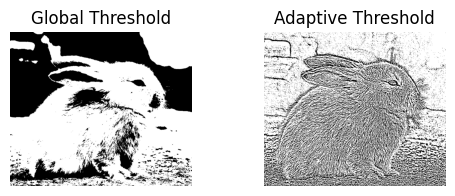

In [ ]:
#SAKSHI(49)
import cv2
import matplotlib.pyplot as plt
image=cv2.imread("Bunny.jpg",0)
threshold=127
_,global_result=cv2.threshold(image,threshold,255,cv2.THRESH_BINARY)
adaptive_result=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(global_result,cmap="gray")
plt.title("Global Threshold")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(adaptive_result,cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

2. Develop a region-growing segmentation tool that segments an image starting from user-selected seed points

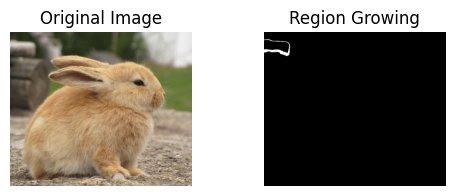

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("Bunny.jpg")
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
seed=(100,100)
threshold=20
visited=np.zeros(gray.shape,dtype=np.uint8)
segmented=np.zeros(gray.shape,dtype=np.uint8)
stack=[seed]
seed_value=int(gray[seed[1],seed[0]])
while stack:
    x,y=stack.pop()
    if x<0 or x>=gray.shape[1] or y<0 or y>=gray.shape[0]:
        continue
    if visited[y,x]:
        continue
    visited[y,x]=1
    if abs(int(gray[y,x])-seed_value)<=threshold:
        segmented[y,x]=255
        stack.extend([(x+1,y),(x-1,y),(x,y+1),(x,y-1)])
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(segmented,cmap="gray")
plt.title("Region Growing")
plt.axis("off")
plt.show()

3. Create a split-merge segmentation demo on a textured or satellite image.

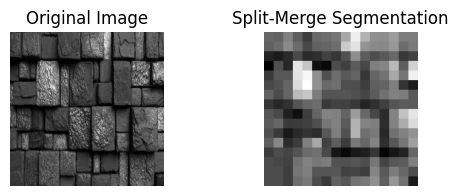

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("textured.jpg",0)
image=cv2.resize(image,(256,256))
result=np.zeros_like(image)
def split(x,y,w,h):
    region=image[y:y+h,x:x+w]
    if w<=16 or np.std(region)<15:
        result[y:y+h,x:x+w]=np.mean(region)
        return
    half=w//2
    split(x,y,half,half)
    split(x+half,y,half,half)
    split(x,y+half,half,half)
    split(x+half,y+half,half,half)
split(0,0,256,256)
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(image,cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(result,cmap="gray")
plt.title("Split-Merge Segmentation")
plt.axis("off")
plt.show()

4. Build a watershed segmentation tool to separate touching or overlapping objects (e.g., coins or cells).

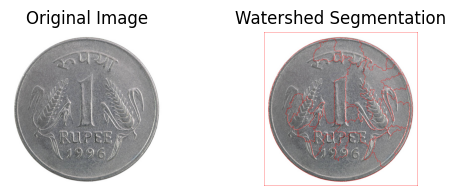

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("One.jpg")
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
_,binary=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
kernel=np.ones((3,3),np.uint8)
opening=cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel,iterations=2)
sure_bg=cv2.dilate(opening,kernel,iterations=3)
dist=cv2.distanceTransform(opening,cv2.DIST_L2,5)
_,sure_fg=cv2.threshold(dist,0.4*dist.max(),255,0)
sure_fg=np.uint8(sure_fg)
unknown=cv2.subtract(sure_bg,sure_fg)
_,markers=cv2.connectedComponents(sure_fg)
markers=markers+1
markers[unknown==255]=0
result=image.copy()
markers=cv2.watershed(result,markers)
result[markers==-1]=[0,0,255]
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

5. Develop a K-means or mean-shift colour segmentation tool that clusters image regions by colour similarity.

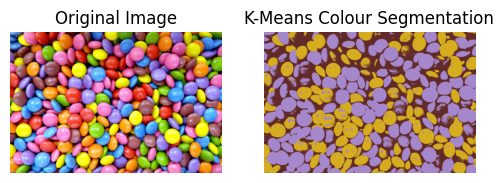

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("colorful.jpg")
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
pixels=image.reshape((-1,3))
pixels=np.float32(pixels)
criteria=(cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER,100,0.2)
k=3
_,labels,centers=cv2.kmeans(pixels,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
centers=np.uint8(centers)
segmented=centers[labels.flatten()]
segmented=segmented.reshape(image.shape)
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(segmented)
plt.title("K-Means Colour Segmentation")
plt.axis("off")
plt.show()

6. Create an interactive foreground-extraction tool using a graph-based method such as GrabCut.

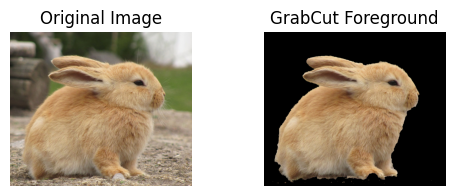

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("Bunny.jpg")
mask=np.zeros(image.shape[:2],np.uint8)
background=np.zeros((1,65),np.float64)
foreground=np.zeros((1,65),np.float64)
height,width=image.shape[:2]
rectangle=(10,10,width-20,height-20)
cv2.grabCut(image,mask,rectangle,background,foreground,5,cv2.GC_INIT_WITH_RECT)
result=np.where((mask==2)|(mask==0),0,1).astype("uint8")
segmented=image*result[:,:,np.newaxis]
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(segmented,cv2.COLOR_BGR2RGB))
plt.title("GrabCut Foreground")
plt.axis("off")
plt.show()

7. Build a normalized-cut based segmentation demo that partitions an image into meaningful regions.

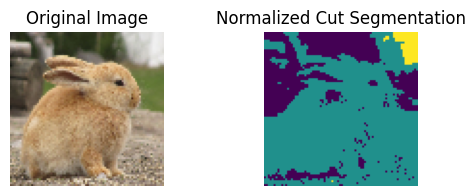

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
image=cv2.imread("Bunny.jpg")
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
image=cv2.resize(image,(80,80))
pixels=image.reshape((-1,3))
model=SpectralClustering(n_clusters=3,affinity="nearest_neighbors",random_state=42)
labels=model.fit_predict(pixels)
segmented=labels.reshape(80,80)
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(segmented,cmap="viridis")
plt.title("Normalized Cut Segmentation")
plt.axis("off")
plt.show()

8. Develop a medical image segmentation tool (e.g., isolating a tumour or organ outline from an image).

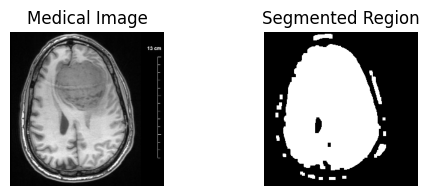

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("brain.jpg",0)
image=cv2.resize(image,(256,256))
_,segmented=cv2.threshold(image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
kernel=np.ones((3,3),np.uint8)
segmented=cv2.morphologyEx(segmented,cv2.MORPH_OPEN,kernel,iterations=2)
segmented=cv2.morphologyEx(segmented,cv2.MORPH_CLOSE,kernel,iterations=2)
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(image,cmap="gray")
plt.title("Medical Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(segmented,cmap="gray")
plt.title("Segmented Region")
plt.axis("off")
plt.show()

9. Create a license-plate or text-region segmentation tool that isolates text areas from vehicle or document images.

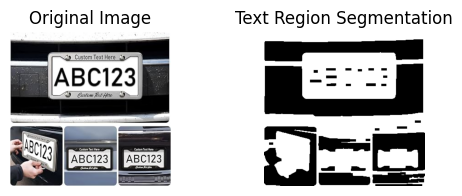

In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("numberPlate.jpg")
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
blur=cv2.GaussianBlur(gray,(5,5),0)
_,binary=cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(5,3))
text_region=cv2.morphologyEx(binary,cv2.MORPH_CLOSE,kernel,iterations=2)
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(text_region,cmap="gray")
plt.title("Text Region Segmentation")
plt.axis("off")
plt.show()

10. Build an evaluation dashboard that compares segmentation accuracy (IoU / Dice score) of different methods against ground-truth masks.

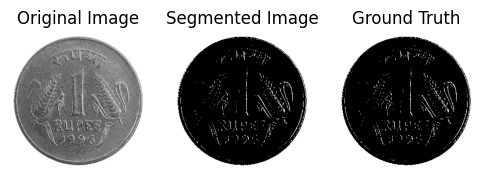

IoU Score: 1.0
Dice Score: 1.0


In [ ]:
#SAKSHI(49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread("One.jpg",0)
image=cv2.resize(image,(256,256))
_,segmented=cv2.threshold(image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ground_truth=segmented.copy()
cv2.imwrite("segmented.png",segmented)
cv2.imwrite("ground_truth.png",ground_truth)
pred=segmented>127
truth=ground_truth>127
intersection=np.logical_and(pred,truth).sum()
union=np.logical_or(pred,truth).sum()
iou=intersection/union
dice=(2*intersection)/(pred.sum()+truth.sum())
plt.figure(figsize=(6,1))
plt.subplot(1,3,1)
plt.imshow(image,cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(segmented,cmap="gray")
plt.title("Segmented Image")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(ground_truth,cmap="gray")
plt.title("Ground Truth")
plt.axis("off")
plt.show()
print("IoU Score:",iou)
print("Dice Score:",dice)